Loading spatial datasets...
 - OSM Roads count: 7095
 - PrevisIA Traces count: 35791
Highway value counts checked successfully.
Projected dataset to local metric CRS: EPSG:31982
PrevisIA traces successfully assigned 'unclassified' highway tags!


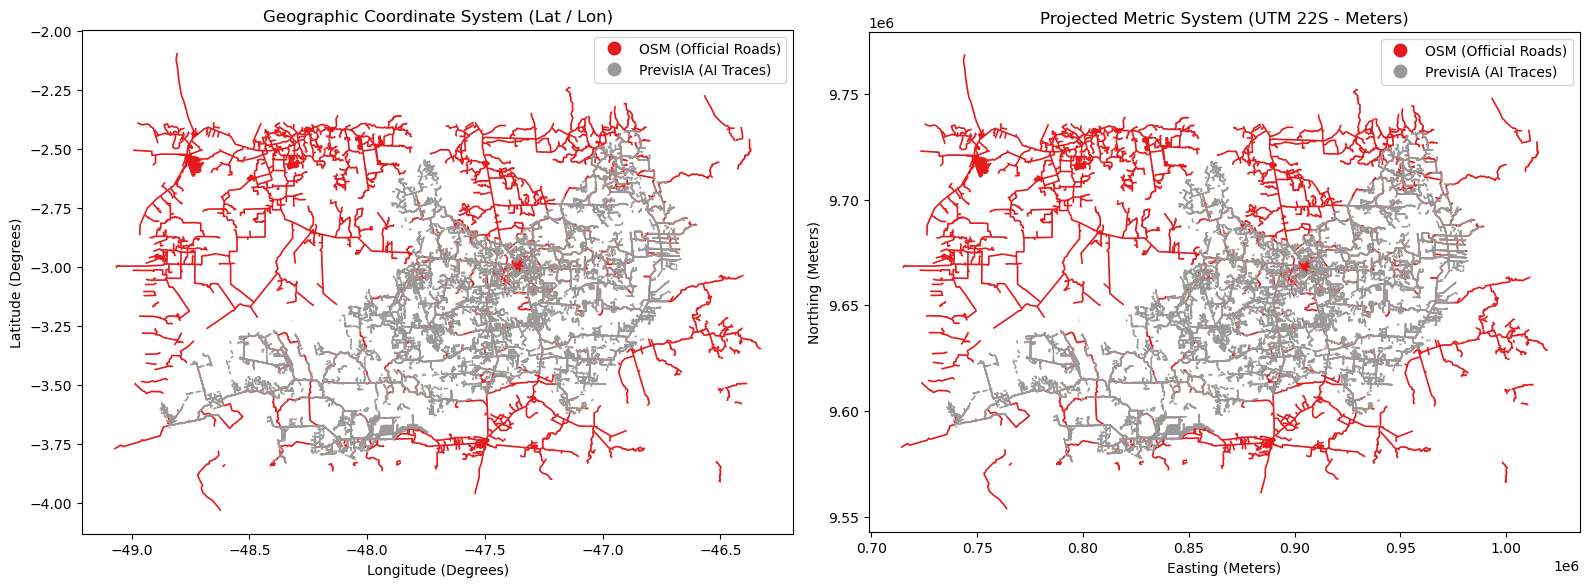

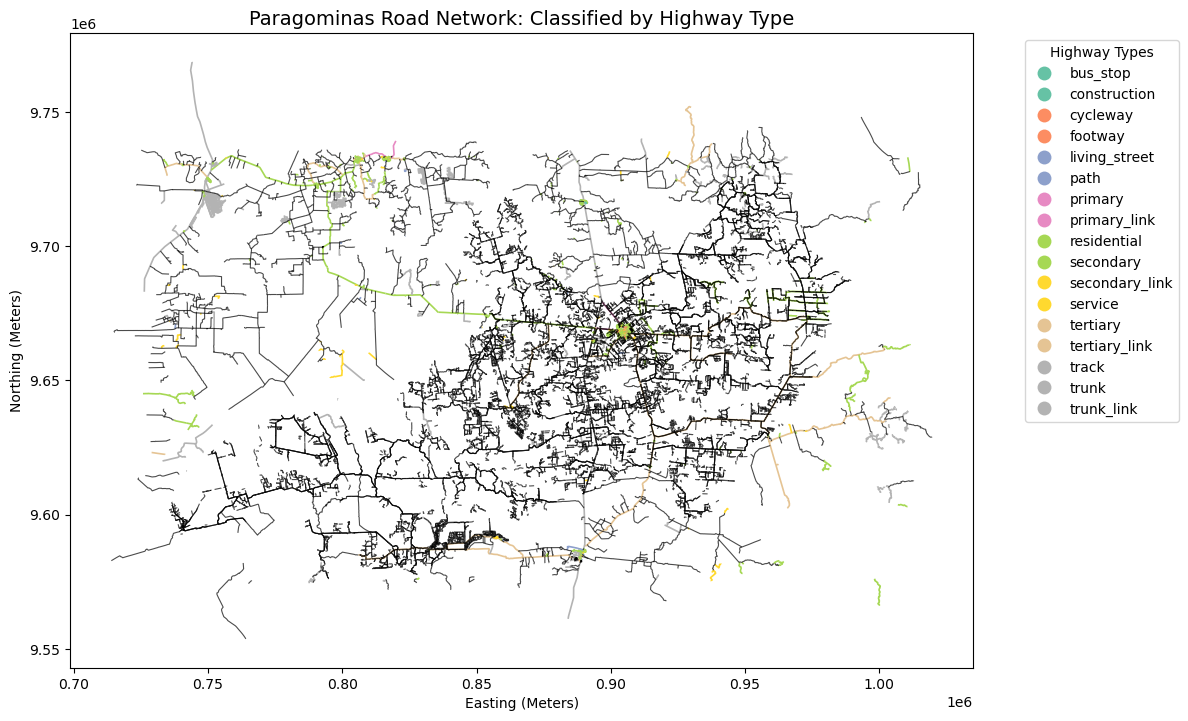

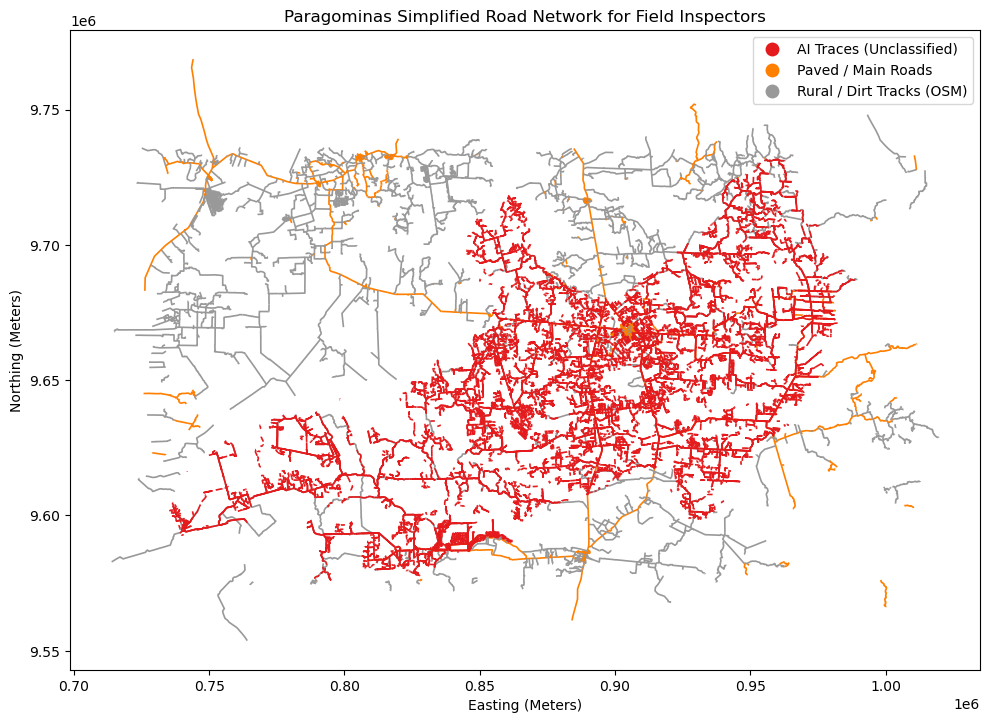

Saving combined dataset to combined_roads_paragominas_metric_units.geojson...
Dataset saved successfully.


In [1]:
import pandas as pd
import geopandas as gpd
from shapely.ops import snap
import matplotlib.pyplot as plt

# Define absolute paths using raw strings (r"...")
osm_path = r"C:\Users\308ca\Desktop\Amazonia\Data\participant-package\participant-package\challenge-3\roads-osm-paragominas.geojson"
previsia_path = r"C:\Users\308ca\Desktop\Amazonia\Data\participant-package\participant-package\challenge-3\roads-previsia-2025-paragominas.geojson"

print("Loading spatial datasets...")
osm_gdf = gpd.read_file(osm_path)
previsia_gdf = gpd.read_file(previsia_path)

# Tag each dataset with an origin identifier column
osm_gdf['source'] = 'OSM (Official Roads)'
previsia_gdf['source'] = 'PrevisIA (AI Traces)'

# Inspect raw OSM data characteristics
print(f" - OSM Roads count: {len(osm_gdf)}")
print(f" - PrevisIA Traces count: {len(previsia_gdf)}")
highway_counts = osm_gdf['highway'].value_counts(dropna=False)
surface_counts = osm_gdf['surface'].value_counts(dropna=False)
print("Highway value counts checked successfully.")

# Create unified geographic lat/lon GeoDataFrame (EPSG:4326)
combined_gdf_latlon = pd.concat([osm_gdf, previsia_gdf], ignore_index=True)
if combined_gdf_latlon.crs is None:
    combined_gdf_latlon.set_crs("EPSG:4326", inplace=True)
else:
    combined_gdf_latlon = combined_gdf_latlon.to_crs("EPSG:4326")

# Create projected metric version for spatial calculations (EPSG:31982 - UTM Zone 22S)
target_crs = "EPSG:31982"
combined_gdf_meters = combined_gdf_latlon.to_crs(target_crs)
print(f"Projected dataset to local metric CRS: {target_crs}")

# Assign default highway attribute to PrevisIA rows since they lack it
combined_gdf_meters.loc[combined_gdf_meters['source'] == 'PrevisIA (AI Traces)', 'highway'] = 'unclassified'
print("PrevisIA traces successfully assigned 'unclassified' highway tags!")

# Visualize side-by-side subplots (Lat/Lon vs Meters)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

combined_gdf_latlon.plot(ax=ax1, column='source', cmap='Set1', linewidth=1.2, legend=True)
ax1.set_title("Geographic Coordinate System (Lat / Lon)", fontsize=12)
ax1.set_xlabel("Longitude (Degrees)")
ax1.set_ylabel("Latitude (Degrees)")

combined_gdf_meters.plot(ax=ax2, column='source', cmap='Set1', linewidth=1.2, legend=True)
ax2.set_title("Projected Metric System (UTM 22S - Meters)", fontsize=12)
ax2.set_xlabel("Easting (Meters)")
ax2.set_ylabel("Northing (Meters)")

plt.tight_layout()
plt.show()

# Visualize detailed highway-type map with black unclassified lines
fig, ax = plt.subplots(figsize=(12, 12))
other_roads = combined_gdf_meters[combined_gdf_meters['highway'] != 'unclassified']
unclassified_roads = combined_gdf_meters[combined_gdf_meters['highway'] == 'unclassified']

other_roads.plot(
    ax=ax, 
    column='highway', 
    cmap='Set2', 
    linewidth=1.2, 
    legend=True,
    legend_kwds={'title': 'Highway Types', 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
)

unclassified_roads.plot(
    ax=ax, color='black', linewidth=0.8, alpha=0.7, label='Unclassified / PrevisIA Traces'
)

plt.title("Paragominas Road Network: Classified by Highway Type", fontsize=14)
plt.xlabel("Easting (Meters)")
plt.ylabel("Northing (Meters)")
plt.tight_layout()
plt.savefig('Roads_By_Highway_Type.png')
plt.show()

# Create simplified group classification
def simplify_highway(row):
    h_type = str(row['highway']).lower()
    if row['source'] == 'PrevisIA (AI Traces)':
        return 'AI Traces (Unclassified)'
    elif h_type in ['primary', 'secondary', 'tertiary', 'trunk', 'motorway', 'residential']:
        return 'Paved / Main Roads'
    else:
        return 'Rural / Dirt Tracks (OSM)'

combined_gdf_meters['road_group'] = combined_gdf_meters.apply(simplify_highway, axis=1)

fig, ax = plt.subplots(figsize=(10, 10))
combined_gdf_meters.plot(ax=ax, column='road_group', cmap='Set1', linewidth=1.2, legend=True)
plt.title("Paragominas Simplified Road Network for Field Inspectors", fontsize=12)
plt.xlabel("Easting (Meters)")
plt.ylabel("Northing (Meters)")
plt.tight_layout()
plt.savefig('Roads_By_Highway_Type_Simplified.png')
plt.show()

# Save the clean processed dataset for the upcoming NetworkX graph step
output_filename = "combined_roads_paragominas_metric_units.geojson"
print(f"Saving combined dataset to {output_filename}...")
combined_gdf_meters.to_file(output_filename, driver="GeoJSON")
print("Dataset saved successfully.")